Real counts: {'.jpg': 41150, '.obj': 27434, '.mtl': 13717, '.png': 27434}
Fake counts: {'.jpg': 24462, '.obj': 16308, '.mtl': 8154, '.png': 16308}
Total counts: {'.jpg': 65612, '.png': 43742, '.obj': 43742, '.mtl': 21871}


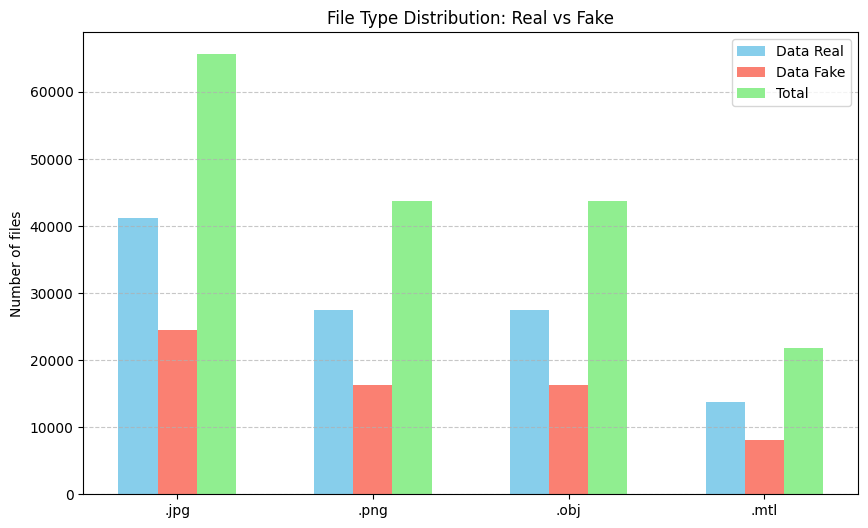

In [4]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_PATH_REAL = "D://DATA_ROOT//REAL"
DATA_PATHS_FAKE = [
    "D://DATA_ROOT//render_3d",
    "D://DATA_ROOT//FAKE_RENDER"
]

file_types = ['.jpg', '.png', '.obj', '.mtl']

def count_file_types(root_paths, types=file_types):
    """
    Đếm số lượng file theo từng loại trong nhiều folder gốc
    """
    counts = defaultdict(int)
    
    for root_path in root_paths:
        if not os.path.exists(root_path):
            continue
        for dirpath, dirnames, filenames in os.walk(root_path):
            for f in filenames:
                ext = os.path.splitext(f)[1].lower()
                if ext in types:
                    counts[ext] += 1
    return counts

real_counts = count_file_types([DATA_PATH_REAL])
fake_counts = count_file_types(DATA_PATHS_FAKE)

total_counts = {ext: real_counts.get(ext,0) + fake_counts.get(ext,0) for ext in file_types}

print("Real counts:", dict(real_counts))
print("Fake counts:", dict(fake_counts))
print("Total counts:", total_counts)

x = range(len(file_types))
plt.figure(figsize=(10,6))

plt.bar([i-0.2 for i in x], [real_counts.get(ext,0) for ext in file_types], width=0.2, label='Data Real', color='skyblue')
plt.bar(x, [fake_counts.get(ext,0) for ext in file_types], width=0.2, label='Data Fake', color='salmon')
plt.bar([i+0.2 for i in x], [total_counts.get(ext,0) for ext in file_types], width=0.2, label='Total', color='lightgreen')

plt.xticks(x, file_types)
plt.ylabel('Number of files')
plt.title('File Type Distribution: Real vs Fake')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()